In [127]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import jax
import jax.numpy as jnp
import optax
from scipy.spatial import cKDTree
import scipy
from functools import partial
%matplotlib widget

In [128]:
s11_transmitter = np.loadtxt(   '/Users/dominiv/research/data/S11_Transmitter.csv', delimiter=',', skiprows=1)
s11_aut = np.loadtxt( '/Users/dominiv/research/data/S11_AUT.csv', delimiter=',', skiprows=1)
s12_atu_t = np.loadtxt('/Users/dominiv/research/data/S12_AUT_to_Trans.csv', delimiter=',', skiprows=1)
inc = 201
ang = 361
print(s11_transmitter.shape)

(72561, 4)


In [129]:
gain_100 = np.loadtxt('/Users/dominiv/research/data/3D_Realized_Gain_Plot_at_100MHz_LinearScale.csv', delimiter=',', skiprows=1)
gain_150 = np.loadtxt('/Users/dominiv/research/data/3D_Realized_Gain_Plot_at_150MHz_LinearScale.csv', delimiter=',', skiprows=1)
gain_200 = np.loadtxt('/Users/dominiv/research/data/3D_Realized_Gain_Plot_at_200MHz_LinearScale.csv', delimiter=',', skiprows=1)
gain_250 = np.loadtxt('/Users/dominiv/research/data/3D_Realized_Gain_Plot_at_250MHz_LinearScale.csv', delimiter=',', skiprows=1)

In [130]:
dipole_gain_100 = np.loadtxt('/Users/dominiv/research/data/3D_Realized_Gain_Plot_dipole_at_100MHz_LinearScale.csv', delimiter=',', skiprows=1)
dipole_gain_150 = np.loadtxt('/Users/dominiv/research/data/3D_Realized_Gain_Plot_dipole_at_150MHz_LinearScale.csv', delimiter=',', skiprows=1)
dipole_gain_200 = np.loadtxt('/Users/dominiv/research/data/3D_Realized_Gain_Plot_dipole_at_200MHz_LinearScale.csv', delimiter=',', skiprows=1)
dipole_gain_250 = np.loadtxt('/Users/dominiv/research/data/3D_Realized_Gain_Plot_dipole_at_250MHz_LinearScale.csv', delimiter=',', skiprows=1)

In [131]:
nside = 32
npix = hp.nside2npix(nside)
beam_thetas = np.deg2rad(gain_100[:, 1])
beam_phis =   np.deg2rad(gain_100[:, 0])

# theta, phi, gain_lin = ...  (1D arrays)

# Sample unit vectors: shape (Nsamp, 3)
def hfss_map(gain):
    sample_vec = np.asarray(hp.ang2vec(beam_thetas, beam_phis))
    if sample_vec.shape[0] == 3 and sample_vec.ndim == 2:
        sample_vec = sample_vec.T
    
    tree = cKDTree(sample_vec)
    
    pix_vec = np.asarray(hp.pix2vec(nside, np.arange(npix))).T
    
    k = 8
    dist, idx = tree.query(pix_vec, k=k)
    
    if k == 1:
        dist = dist[:, None]
        idx = idx[:, None]
    
    eps = 1e-12
    w = 1.0 / (dist + eps)**2
    w /= w.sum(axis=1, keepdims=True)
    
    hmap = (w * gain[:, 2][idx]).sum(axis=1)
    return hmap

beam_100 = hfss_map(gain_100)
beam_150 = hfss_map(gain_150)
beam_200 = hfss_map(gain_200)
beam_250 = hfss_map(gain_250)

dipole_beam_100 = hfss_map(dipole_gain_100)
dipole_beam_150 = hfss_map(dipole_gain_150)
dipole_beam_200 = hfss_map(dipole_gain_200)
dipole_beam_250 = hfss_map(dipole_gain_250)

In [132]:
phis =   np.deg2rad(s11_transmitter[:, 0][::inc])
thetas = np.deg2rad(s11_transmitter[:, 1][::inc])
freqs = s11_transmitter[:inc, 2]

def db_lin(db):
    # return 10**(db/10)
    return db

s11_t = db_lin(s11_transmitter[:, 3])
s11_t = s11_t.reshape(ang, inc)
# s11_t = np.reshape(s11_t, newshape=(inc, s11_t.shape[0]//inc))

s11_bowtie = db_lin(s11_aut[:, 3])
s11_bowtie = s11_bowtie.reshape(ang, inc)
# s11_bowtie = np.reshape(s11_bowtie, newshape=(inc, s11_bowtie.shape[0]//inc))

s12_bowtie = db_lin(s12_atu_t[:, 3])
s12_bowtie = s12_bowtie.reshape(ang, inc)
# s12_bowtie = np.reshape(s12_bowtie, newshape=(inc, s12_bowtie.shape[0]//inc))
phis.shape, thetas.shape, freqs.shape, s11_t.shape, s11_bowtie.shape, s12_bowtie.shape

((361,), (361,), (201,), (361, 201), (361, 201), (361, 201))

In [133]:

c = 3e8 # m/s
# def az_rot(alpha):
#     R = np.array([[np.cos(alpha), -np.sin(alpha), 0],
#                  [np.sin(alpha), np.cos(alpha), 0],
#                  [0, 0, 1]])
#     return R


def az_rot(alpha):
    alpha = jnp.asarray(alpha)
    c = jnp.cos(alpha)
    s = jnp.sin(alpha)
    z = jnp.zeros_like(alpha)
    o = jnp.ones_like(alpha)

    R = jnp.stack([
        jnp.stack([ c, -s, z], axis=-1),
        jnp.stack([ s,  c, z], axis=-1),
        jnp.stack([ z,  z, o], axis=-1),
    ], axis=-2)

    return R


def el_rot(beta):
    beta = jnp.asarray(beta)
    c = jnp.cos(beta)
    s = jnp.sin(beta)
    z = jnp.zeros_like(beta)
    o = jnp.ones_like(beta)

    R = jnp.stack([
        jnp.stack([ c,  z,  s], axis=-1),
        jnp.stack([ z,  o,  z], axis=-1),
        jnp.stack([-s,  z,  c], axis=-1),
    ], axis=-2)

    return R


def polarization(ang):
    start_vec  = jnp.array([0.0, 0.0, 1.0])
    # dipole_vec = jnp.array([1.0, 0.0,  0.0])

    ang = jnp.asarray(ang)

    # Accept either shape (..., 2) or (2, ...)
    if ang.shape[-1] == 2:
        az = ang[..., 0]
        el = ang[..., 1]
    elif ang.shape[0] == 2:
        az = ang[0, ...]
        el = ang[1, ...]
    else:
        raise ValueError("ang must have shape (..., 2) or (2, ...) with [az, el].")

    # Rs = el_rot(el) @ az_rot(az)        # (..., 3, 3)
    Rs = az_rot(az) @ el_rot(el)        # (..., 3, 3)
    new_vec = Rs @ start_vec            # (..., 3)

    return new_vec
    # return jnp.abs(jnp.einsum("i,...i->...", dipole_vec, new_vec))**2


def pol_conv(vec, Rvec, eps=1e-12):
    # vec: (3,) ; Rvec: (...,3)
    # Use Hermitian inner product for complex polarization vectors
    num = jnp.abs(jnp.einsum("i,...i->...", jnp.conj(vec), Rvec))**2
    den = (jnp.linalg.norm(vec)**2) * (jnp.linalg.norm(Rvec, axis=-1)**2)
    return num / jnp.maximum(den, eps)


def friis(freqs, R, s11t, s11r, Dt, Dr, ang, all_freq=False, pol=True):
    freqs = jnp.asarray(freqs)
    R     = jnp.asarray(R)
    s11t  = jnp.asarray(s11t)
    s11r  = jnp.asarray(s11r)
    Dt    = jnp.asarray(Dt)
    Dr    = jnp.asarray(Dr)

    et = 1.0
    er = 1.0

    lam = c / freqs                               # broadcasts over freqs
    space = (lam / (4.0 * jnp.pi * R))**2          # broadcasts over freqs and/or R

    # t_loss = 1.0 - (10.0**(s11t / 20.0))**2
    # r_loss = 1.0 - (10.0**(s11r / 20.0))**2
    t_loss = 1.0
    r_loss = 1.0

    dipole_vec = jnp.array([1.0, 0.0, 0.0])
    plf = polarization(ang)                       # shape (...) (e.g., (N,) if ang is (N,2))
    plf = pol_conv(plf, dipole_vec)
    if all_freq:
        plf = plf[:, None]
    # plf = plf[:, None]

    # Everything broadcasts to a common shape
    if pol:
        # ratio = et * er * t_loss * r_loss * space * Dt * Dr * plf
        ratio = et * er * t_loss * r_loss * space * Dt * Dr * plf
    else:
        ratio = et * er * t_loss * r_loss * space * Dt * Dr
    return ratio


R = 10
freq_ind = 150
test_freq = freqs[freq_ind] * 1e6
test_s11t = s11_t[0, freq_ind]
# test_s11r = s11_bowtie[0, freq_ind]
test_s11r = s11_t[0, freq_ind]
test_az = np.linspace(np.deg2rad(0), np.deg2rad(180), 361, endpoint=True)
test_el = np.full_like(test_az, fill_value=np.deg2rad(90))
# test_ang = np.stack((test_az, test_el))
test_ang = np.stack((phis, thetas))
fake_dr = 3/2
Dt = 3/2


In [134]:
def friis_pol(freqs, R, s11t, s11r, Dt, Dr, plf, all_freq=False, pol=True):
    freqs = jnp.asarray(freqs)
    R     = jnp.asarray(R)
    s11t  = jnp.asarray(s11t)
    s11r  = jnp.asarray(s11r)
    Dt    = jnp.asarray(Dt)
    Dr    = jnp.asarray(Dr)
    plf   = jnp.asarray(plf)

    et = 1.0
    er = 1.0

    lam = c / freqs                               # broadcasts over freqs
    space = (lam / (4.0 * jnp.pi * R))**2          # broadcasts over freqs and/or R

    # Works for scalar or array S11 in dB
    # t_loss = 1.0 - (10.0**(s11t / 20.0))**2
    # r_loss = 1.0 - (10.0**(s11r / 20.0))**2
    t_loss = 1.0
    r_loss = 1.0

    if pol:
        # ratio = et * er * t_loss * r_loss * space * Dt * Dr * plf
        # ratio = et * er * t_loss * r_loss * space * Dt * Dr * plf
        ratio = t_loss * space * Dt * Dr * plf
    else:
        ratio = et * er * t_loss * r_loss * space * Dt * Dr
    return ratio
    # return 10*jnp.log10(ratio)

In [135]:
def ang2vec(theta, phi):
    # theta = colatitude [0,pi], phi = azimuth [0,2pi)
    st = np.sin(theta)
    return np.stack([st*np.cos(phi), st*np.sin(phi), np.cos(theta)], axis=-1)

def vec2ang(v):
    v = v / np.linalg.norm(v, axis=-1, keepdims=True)
    theta = np.arccos(np.clip(v[..., 2], -1.0, 1.0))
    phi = (np.arctan2(v[..., 1], v[..., 0]) % (2*np.pi))
    return theta, phi

def rot_y(a):
    ca, sa = np.cos(a), np.sin(a)
    return np.array([[ ca, 0.0,  sa],
                     [0.0, 1.0, 0.0],
                     [-sa, 0.0,  ca]])

def new_origin(theta, phi):
    """
    Rotate sphere so that HFSS +z becomes healpy +x (map center).
    Assumes theta is *colatitude* (0 at +z).
    """
    R = rot_y(+np.pi/2)          # +z -> +x
    v = ang2vec(theta, phi)
    v2 = v @ R.T
    return vec2ang(v2)
new_thetas, new_phis = new_origin(thetas, phis)
hit_pxs = hp.ang2pix(theta=(new_thetas), phi=(new_phis), nside=nside)

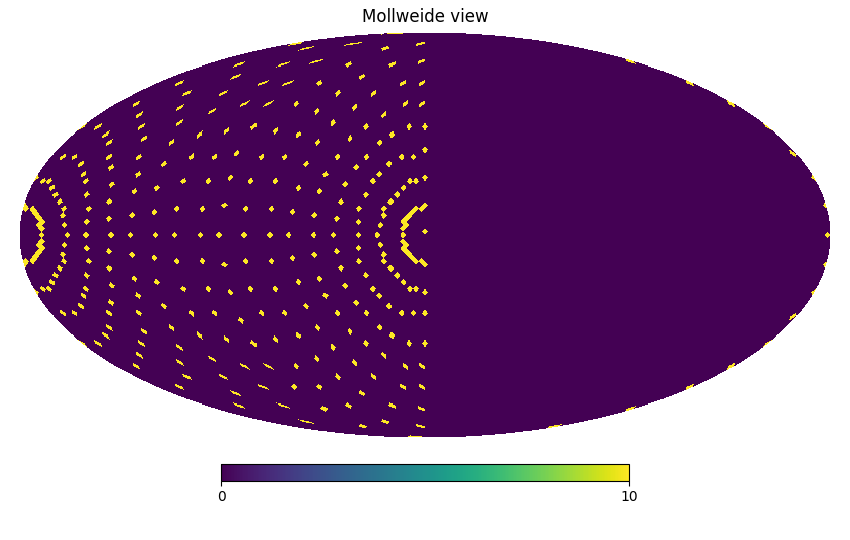

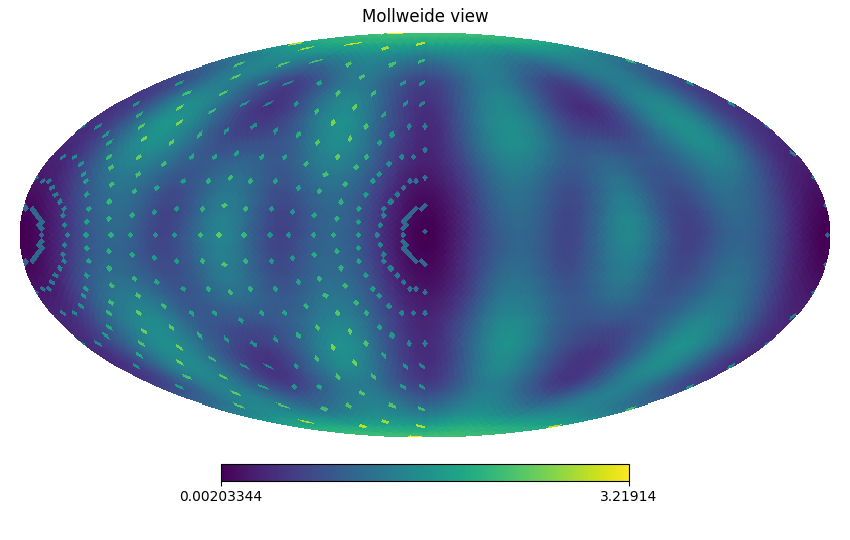

In [136]:
vro = np.full(shape=(hp.nside2npix(nside=nside)), fill_value=0)
vro[hit_pxs] += 10
copy_250 = np.asarray(beam_250).copy()
copy_250[hit_pxs] += 1
hp.mollview(vro, rot=(0, 0, 0))
hp.mollview(copy_250)

In [137]:
real_gain = beam_100[hit_pxs]
freq_ind = 50
# Dr = jnp.max(dipole_beam_100)
top = hp.ang2pix(nside, jnp.deg2rad(0), jnp.deg2rad(0))
# Dt = jnp.max(dipole_beam_250)
# Dt = dipole_beam_250[top]
Dt = dipole_beam_100[6]
ts11 = jnp.full(shape = (361,), fill_value=s11_t[10, freq_ind])
y = 10**(s12_bowtie[:, freq_ind]/10)
new_vec = polarization([phis, thetas])
lr = 1e-5
steps = 100000

def loss_fnc(pol0):
    pol0 = pol_conv(pol0, new_vec)
    model = friis_pol(freqs[freq_ind]*1e6, R, s11_t[:, freq_ind], s11_bowtie[:, freq_ind], 
                  Dt, real_gain, pol0, all_freq=False, pol=True)
    loss = jnp.mean((y - model)**2)
    return loss

optimizer = optax.adam(learning_rate=lr, eps=1e-21)
# optimizer = optax.adam(learning_rate=lr)
params_init = jnp.array([1.0, 0.0, 0.0])


params_raw = params_init
opt_state  = optimizer.init(params_raw)

@jax.jit
def train_step(params_raw, opt_state):
    loss_val, grads = jax.value_and_grad(loss_fnc)(params_raw)
    updates, opt_state = optimizer.update(grads, opt_state, params_raw)
    params_raw = optax.apply_updates(params_raw, updates)
    return params_raw, opt_state, loss_val

loss_list = []

for k in range(steps):
    params_raw, opt_state, losses = train_step(params_raw, opt_state)

    losses_np = np.asarray(jax.device_get(losses))
    loss_list.append(losses_np)

final_pol = params_raw
print(final_pol)
pol_p = final_pol.copy()
print(final_pol)
print(loss_list[-1])

[5.7688963e-01 3.0081836e-03 5.5855775e-04]
[5.7688963e-01 3.0081836e-03 5.5855775e-04]
1.9006494e-14


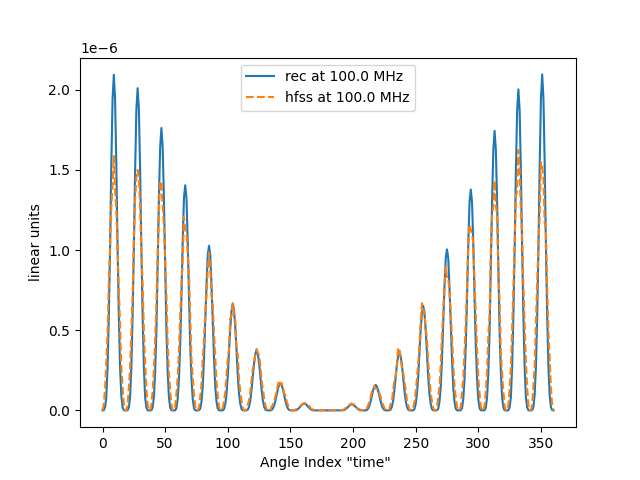

In [138]:
best_pol = pol_conv(final_pol, new_vec)

pol_solve = friis_pol(freqs[freq_ind]*1e6, R, s11_t[:, freq_ind], s11_bowtie[:, freq_ind], 
                  Dt, real_gain, best_pol, all_freq=False, pol=True)
plt.figure()
plt.plot(pol_solve, label=f'rec at {freqs[freq_ind]} MHz')
# plt.plot(10**(s12_bowtie[:, freq_ind]/10), ls='--')
plt.plot(y, ls='--', label=f'hfss at {freqs[freq_ind]} MHz')
plt.xlabel('Angle Index "time" ')
plt.ylabel('linear units')
plt.legend()
plt.show()

In [139]:
def friis(freqs, R, s11t, s11r, Dt, a, E1, b, E2, ang, all_freq=False):
    freqs = jnp.asarray(freqs)
    R     = jnp.asarray(R)
    s11t  = jnp.asarray(s11t)
    s11r  = jnp.asarray(s11r)
    Dt    = jnp.asarray(Dt)
    Dr    = jnp.asarray(Dr)

    et = 1.0
    er = 1.0

    lam = c / freqs                               # broadcasts over freqs
    space = (lam / (4.0 * jnp.pi * R))**2          # broadcasts over freqs and/or R

    # t_loss = 1.0 - (10.0**(s11t / 20.0))**2
    # r_loss = 1.0 - (10.0**(s11r / 20.0))**2
    t_loss = 1.0
    r_loss = 1.0

    dipole_vec = jnp.array([1.0, 0.0, 0.0])
    plf = polarization(ang)                       # shape (...) (e.g., (N,) if ang is (N,2))
    plf = pol_conv(plf, dipole_vec)
    Dr = jnp.abs(a*E1 + b*E2)**2
    if all_freq:
        plf = plf[:, None]
    ratio = et * er * t_loss * r_loss * space * Dt * Dr * plf
    return ratio

In [140]:
import jax.numpy as jnp

def az_rot(alpha):
    alpha = jnp.asarray(alpha)
    c = jnp.cos(alpha)
    s = jnp.sin(alpha)
    z = jnp.zeros_like(alpha)
    o = jnp.ones_like(alpha)
    return jnp.stack([
        jnp.stack([ c, -s, z], axis=-1),
        jnp.stack([ s,  c, z], axis=-1),
        jnp.stack([ z,  z, o], axis=-1),
    ], axis=-2)

def el_rot(beta):
    beta = jnp.asarray(beta)
    c = jnp.cos(beta)
    s = jnp.sin(beta)
    z = jnp.zeros_like(beta)
    o = jnp.ones_like(beta)
    return jnp.stack([
        jnp.stack([ c,  z,  s], axis=-1),
        jnp.stack([ z,  o,  z], axis=-1),
        jnp.stack([-s,  z,  c], axis=-1),
    ], axis=-2)

def bowtie_axis_from_ang(ang, start_vec=jnp.array([0.0, 0.0, 1.0])):
    """
    Rotates a body-frame axis (e.g., bowtie polarization axis) into lab frame.
      ang: (...,2) or (2,...) with [az, el]
      start_vec: (3,) axis in bowtie body frame at zero angles
    Returns: (...,3) rotated axis in lab frame
    """
    ang = jnp.asarray(ang)
    if ang.shape[-1] == 2:
        az = ang[..., 0]
        el = ang[..., 1]
    elif ang.shape[0] == 2:
        az = ang[0, ...]
        el = ang[1, ...]
    else:
        raise ValueError("ang must have shape (...,2) or (2,...) with [az, el].")

    # Keep your convention:
    Rs = az_rot(az) @ el_rot(el)   # (...,3,3)
    return Rs @ jnp.asarray(start_vec)  # (...,3)

def inc_E_dir(p_tx, rhat, eps=1e-12):
    """
    Unit vector of incident far-field E polarization from an ideal short dipole.
      p_tx: (3,) dipole axis unit vector (lab frame)
      rhat: (...,3) unit vector from Tx -> Rx (lab frame)
    Returns: (...,3) unit E direction (transverse to rhat)
    """
    p_tx = jnp.asarray(p_tx)
    rhat = jnp.asarray(rhat)
    v = jnp.cross(p_tx, rhat)
    e = jnp.cross(v, rhat)
    n = jnp.linalg.norm(e, axis=-1, keepdims=True)
    return e / jnp.maximum(n, eps)

def pol_conv(vec, other_vec, eps=1e-12):
    """
    Polarization alignment factor = cos^2(angle(vec, other_vec)).
    Uses Hermitian inner product (safe for complex).
      vec: (...,3) or (3,)
      other_vec: (...,3) or (3,)
    Returns: broadcasted real array (...)
    """
    vec = jnp.asarray(vec)
    other_vec = jnp.asarray(other_vec)
    num = jnp.abs(jnp.einsum("...i,...i->...", jnp.conj(vec), other_vec))**2
    den = (jnp.linalg.norm(vec, axis=-1)**2) * (jnp.linalg.norm(other_vec, axis=-1)**2)
    return num / jnp.maximum(den, eps)

def plf_from_geometry(ang, p_tx, rhat, start_vec=jnp.array([0.0, 0.0, 1.0])):
    """
    Physically-correct PLF between rotated bowtie axis and incident E from dipole.
      ang: (...,2) [az, el]
      p_tx: (3,) dipole axis (lab frame)
      rhat: (...,3) unit vector Tx->Rx (lab frame)
      start_vec: (3,) bowtie axis in body frame (choose this carefully!)
    Returns: (...,) in [0,1]
    """
    p_rx = bowtie_axis_from_ang(ang, start_vec=start_vec)  # (...,3)
    e_inc = inc_E_dir(p_tx, rhat)                          # (...,3)
    return pol_conv(p_rx, e_inc)

p_tx = jnp.array([1.0, 0.0, 0.0])
rhat = jnp.array([0.0, 0.0, 1.0])
plf = plf_from_geometry(test_ang, p_tx, rhat, start_vec=jnp.array([1.0, 0.0, 0.0]))


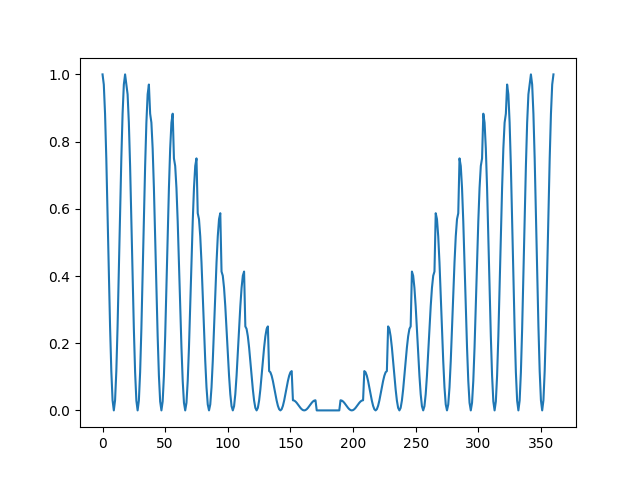

In [141]:
plt.figure()
plt.plot(plf)
plt.show()

In [1]:
import jax.numpy as jnp

def az_rot(alpha):
    alpha = jnp.asarray(alpha)
    c, s = jnp.cos(alpha), jnp.sin(alpha)
    z = jnp.zeros_like(alpha)
    o = jnp.ones_like(alpha)
    return jnp.stack([
        jnp.stack([ c, -s, z], axis=-1),
        jnp.stack([ s,  c, z], axis=-1),
        jnp.stack([ z,  z, o], axis=-1),
    ], axis=-2)

def el_rot(beta):
    beta = jnp.asarray(beta)
    c, s = jnp.cos(beta), jnp.sin(beta)
    z = jnp.zeros_like(beta)
    o = jnp.ones_like(beta)
    return jnp.stack([
        jnp.stack([ c,  z,  s], axis=-1),
        jnp.stack([ z,  o,  z], axis=-1),
        jnp.stack([-s,  z,  c], axis=-1),
    ], axis=-2)

def bowtie_pol_axis_lab(ang, pol_axis0=jnp.array([0.0, 0.0, 1.0])):
    """
    ang: (...,2) with [az, el] (your convention)
    pol_axis0: (3,) polarization axis at zero orientation (arms direction).
              For you: [0,0,1] because arms along lab-z at ang=(0,0).
    Returns: (...,3) polarization axis in lab xyz after rotation.
    """
    ang = jnp.asarray(ang)
    if ang.shape[-1] == 2:
        az = ang[..., 0]
        el = ang[..., 1]
    elif ang.shape[0] == 2:
        az = ang[0, ...]
        el = ang[1, ...]
    else:
        raise ValueError("ang must have shape (...,2) or (2,...) with [az, el].")

    R = az_rot(az) @ el_rot(el)    # keep your order
    return R @ pol_axis0           # (...,3)

def sph_unit_vectors(theta, phi):
    """
    Physics convention: theta=polar angle from +z, phi=azimuth from +x toward +y.
    Returns e_theta, e_phi with shape (...,3).
    """
    theta = jnp.asarray(theta)
    phi   = jnp.asarray(phi)
    ct, st = jnp.cos(theta), jnp.sin(theta)
    cp, sp = jnp.cos(phi), jnp.sin(phi)

    e_theta = jnp.stack([ct*cp, ct*sp, -st], axis=-1)
    e_phi   = jnp.stack([-sp,   cp,    0*phi], axis=-1)
    return e_theta, e_phi

def ab_from_ang_theta_phi(ang, theta, phi, pol_axis0=jnp.array([0.0, 0.0, 1.0])):
    """
    Computes a,b such that E_port = a*E_theta + b*E_phi for a linear Rx axis.
    """
    p_rx = bowtie_pol_axis_lab(ang, pol_axis0=pol_axis0)  # (...,3)
    e_th, e_ph = sph_unit_vectors(theta, phi)              # (...,3), (...,3)

    a = jnp.einsum("...i,...i->...", p_rx, e_th)
    b = jnp.einsum("...i,...i->...", p_rx, e_ph)
    return a, b

def friis(freqs, R, s11t, s11r, Dt, Etheta, Ephi, ang, theta, phi, all_freq=False):
    freqs = jnp.asarray(freqs)
    R     = jnp.asarray(R)
    Dt    = jnp.asarray(Dt)
    Etheta = jnp.asarray(Etheta)
    Ephi   = jnp.asarray(Ephi)

    lam = c / freqs
    space = (lam / (4.0 * jnp.pi * R))**2

    a, b = ab_from_ang_theta_phi(ang, theta, phi, pol_axis0=jnp.array([0.0,0.0,1.0]))

    Dr = jnp.abs(a*Etheta + b*Ephi)**2
    # Dr = jnp.abs(a*jnp.sqrt(Etheta) + b*jnp.sqrt(Ephi))**2

    if all_freq:
        space = space[:, None]
        Dt = Dt[:, None] if Dt.ndim == 1 else Dt
        Dr = Dr[None, :]

    ratio = space * Dt * Dr * s11t * s11r
    return ratio




In [2]:
def boresight_dir_lab(ang, boresight0=jnp.array([1.0, 0.0, 0.0])):
    # boresight0 is normal to bowtie plane at zero; for yz-plane it's +x
    ang = jnp.asarray(ang)
    if ang.shape[-1] == 2:
        az = ang[..., 0]
        el = ang[..., 1]
    elif ang.shape[0] == 2:
        az = ang[0, ...]
        el = ang[1, ...]
    else:
        raise ValueError("ang must have shape (...,2) or (2,...)")

    R = az_rot(az) @ el_rot(el)
    return R @ boresight0  # (...,3)

def theta_phi_from_rhat(rhat, eps=1e-12):
    rhat = jnp.asarray(rhat)
    x, y, z = rhat[...,0], rhat[...,1], rhat[...,2]
    # normalize defensively
    n = jnp.linalg.norm(rhat, axis=-1)
    x, y, z = x/jnp.maximum(n,eps), y/jnp.maximum(n,eps), z/jnp.maximum(n,eps)

    theta = jnp.arccos(jnp.clip(z, -1.0, 1.0))
    phi = jnp.arctan2(y, x)
    return theta, phi

rhat = boresight_dir_lab(test_ang)         # from gimbal angles
theta, phi = theta_phi_from_rhat(rhat)
a, b = ab_from_ang_theta_phi(test_ang, theta, phi, pol_axis0=jnp.array([0,0,1]))
a.shape, b.shape, theta.shape, phi.shape

NameError: name 'test_ang' is not defined

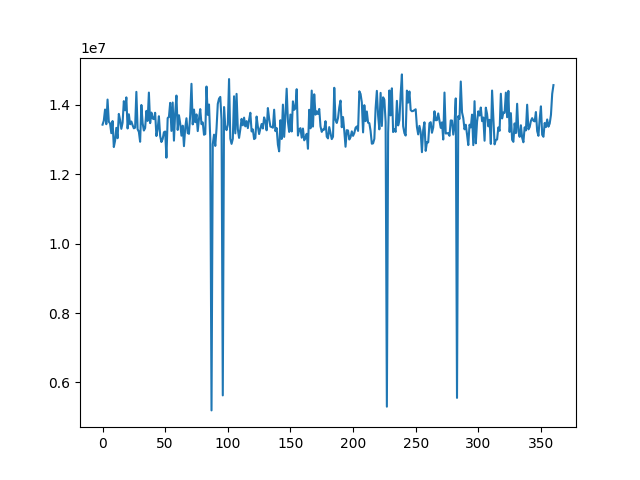

In [254]:
test_friis = friis(freqs[freq_ind], 10, 10**(s11_t[:, freq_ind]/10), 10**(s11_bowtie[:, freq_ind]/10), 3/2, 1, 1, test_ang, theta, phi)
plt.figure()
plt.plot((test_friis))
plt.show()

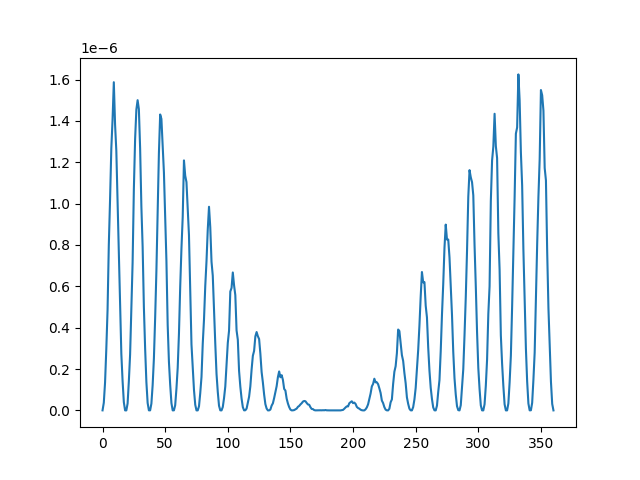

In [145]:
y = 10**(s12_bowtie[:, freq_ind]/10)

plt.figure()
plt.plot(y)
plt.show()

In [257]:

lr = 1e-3
optimizer = optax.adam(learning_rate=lr)
freq_ind = 50
y = 10**(s12_bowtie[:, freq_ind]/10)
# optimizer = optax.adamw(learning_rate=lr, weight_decay=1e-6)
# optimizer = optax.sgd(learning_rate=lr, momentum=.9, nesterov=True)

def loss_fnc(params_raw):
    E_th, E_ph = params_raw
    E_th = jax.nn.softplus(E_th)
    E_ph = jax.nn.softplus(E_ph)
    mod = friis(freqs[freq_ind], 10, 10**(s11_t[:, freq_ind]/10), 10**(s11_bowtie[:, freq_ind]/10), 3/2, E_th, E_ph, test_ang, theta, phi)
    loss = jnp.mean((y - mod) ** 2)
    # loss += decorrelate_loss(m_th, m_ph, hit_pxs)
    # loss = loss + rotated_similarity_reg(m_th, m_ph, hit_pxs, nbr_idx, w, lam=1e-3)
    return loss

@jax.jit
def train_step(params_raw, opt_state):
    loss_val, grads = jax.value_and_grad(loss_fnc)(params_raw)
    updates, opt_state = optimizer.update(grads, opt_state, params_raw)
    params_raw = optax.apply_updates(params_raw, updates)
    return params_raw, opt_state, loss_val

@partial(jax.jit, static_argnames=("chunk_steps",))
def run_chunk(params_raw, opt_state, chunk_steps: int):
    def body(carry, _):
        params_raw, opt_state = carry
        params_raw, opt_state, loss_val = train_step(params_raw, opt_state)
        return (params_raw, opt_state), loss_val

    (params_raw, opt_state), losses = jax.lax.scan(
        body, (params_raw, opt_state), xs=None, length=chunk_steps
    )
    return params_raw, opt_state, losses


th_init = jnp.full_like(thetas, 1)
ph_init = jnp.full_like(phis, 1)

# num_steps   = 5600
num_steps   = 300000
# num_steps   = 32000
chunk_steps = 1000                      # print every 200 steps
n_chunks    = (num_steps + chunk_steps - 1) // chunk_steps

params_raw = (th_init, ph_init)
opt_state  = optimizer.init(params_raw)

loss_list = []
step_ctr = 0

for k in range(n_chunks):
    params_raw, opt_state, losses = run_chunk(params_raw, opt_state, chunk_steps=chunk_steps)
    # params_raw, opt_state, losses = train_step(params_raw, opt_state)

    # Sync HERE so you don't "hang" later:
    losses_np = np.asarray(jax.device_get(losses))
    loss_list.append(losses_np)

    step_ctr += chunk_steps
    print(f"{min(step_ctr, num_steps):05d}  loss={losses_np[-1]:.3e}")

loss_arr = np.concatenate(loss_list)[:num_steps]


# print(loss_list[-1])
print('solver done')
# final_Eth = params_raw[0]
# final_Eph = params_raw[1]

final_Eth = jax.nn.softplus(params_raw[0])
final_Eph = jax.nn.softplus(params_raw[1])



01000  loss=9.966e+13
02000  loss=3.411e+13
03000  loss=1.502e+13
04000  loss=7.486e+12
05000  loss=3.992e+12
06000  loss=2.215e+12
07000  loss=1.260e+12
08000  loss=7.287e+11
09000  loss=4.260e+11
10000  loss=2.511e+11
11000  loss=1.488e+11
12000  loss=8.864e+10
13000  loss=5.298e+10
14000  loss=3.176e+10
15000  loss=1.909e+10
16000  loss=1.149e+10
17000  loss=6.934e+09
18000  loss=4.189e+09
19000  loss=2.535e+09
20000  loss=1.535e+09
21000  loss=9.310e+08
22000  loss=5.650e+08
23000  loss=3.432e+08
24000  loss=2.086e+08
25000  loss=1.269e+08
26000  loss=7.719e+07
27000  loss=4.700e+07
28000  loss=2.862e+07
29000  loss=1.744e+07
30000  loss=1.062e+07
31000  loss=6.481e+06
32000  loss=3.952e+06
33000  loss=2.409e+06
34000  loss=1.471e+06
35000  loss=8.977e+05
36000  loss=5.478e+05
37000  loss=3.342e+05
38000  loss=2.039e+05
39000  loss=1.245e+05
40000  loss=7.607e+04
41000  loss=4.646e+04
42000  loss=2.838e+04
43000  loss=1.733e+04
44000  loss=1.058e+04
45000  loss=6.460e+03
46000  los

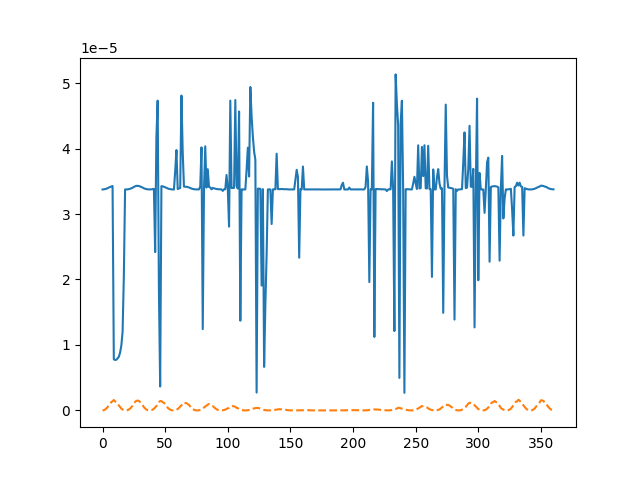

In [258]:

test_friis = friis(freqs[freq_ind], 10, 10**(s11_t[:, freq_ind]/10), 10**(s11_bowtie[:, freq_ind]/10), 3/2, final_Eth, final_Eph, test_ang, theta, phi)

plt.figure()
plt.plot(test_friis)
plt.plot(10**(s12_bowtie[:, freq_ind]/10), ls='--')
plt.show()

In [68]:
import numpy as np
import healpy as hp

def healpix_idx_from_sim_theta_phi(nside, theta, phi, degrees=True, nest=False):
    theta = np.asarray(theta)
    phi   = np.asarray(phi)

    if degrees:
        theta = np.deg2rad(theta)
        phi   = np.deg2rad(phi)

    # wrap phi to [0, 2pi)
    phi = np.mod(phi, 2*np.pi)

    # guard theta: should be [0, pi]
    if np.any(theta < 0) or np.any(theta > np.pi):
        tmin, tmax = float(theta.min()), float(theta.max())
        raise ValueError(f"theta out of range: min={tmin}, max={tmax}. "
                         "Your 'el' may be elevation, or degrees/radians mismatch.")

    return hp.ang2pix(nside, theta, phi, nest=nest)
idx = healpix_idx_from_sim_theta_phi(nside, thetas, phis, degrees=False)

In [81]:
import numpy as np
import healpy as hp

def az_rot_np(alpha):
    c = np.cos(alpha); s = np.sin(alpha)
    z = np.zeros_like(alpha); o = np.ones_like(alpha)
    return np.stack([
        np.stack([ c, -s, z], axis=-1),
        np.stack([ s,  c, z], axis=-1),
        np.stack([ z,  z, o], axis=-1),
    ], axis=-2)

def el_rot_np(beta):
    c = np.cos(beta); s = np.sin(beta)
    z = np.zeros_like(beta); o = np.ones_like(beta)
    return np.stack([
        np.stack([ c,  z,  s], axis=-1),
        np.stack([ z,  o,  z], axis=-1),
        np.stack([-s,  z,  c], axis=-1),
    ], axis=-2)

def ang_as_N2(ang):
    ang = np.asarray(ang)
    if ang.shape[-1] == 2:
        return ang
    if ang.shape[0] == 2:
        return ang.T
    raise ValueError(f"ang must be (N,2) or (2,N), got {ang.shape}")

def sph_to_cart(theta, phi):
    st, ct = np.sin(theta), np.cos(theta)
    sp, cp = np.sin(phi), np.cos(phi)
    return np.stack([st*cp, st*sp, ct], axis=-1)

def cart_to_sph(v):
    v = np.asarray(v)
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    v = v / np.maximum(n, 1e-12)
    x,y,z = v[...,0], v[...,1], v[...,2]
    theta = np.arccos(np.clip(z, -1.0, 1.0))
    phi = np.mod(np.arctan2(y, x), 2*np.pi)
    return theta, phi

def healpix_idx_from_theta_phi(nside, theta, phi, degrees=True, nest=False):
    theta = np.asarray(theta); phi = np.asarray(phi)
    if degrees:
        theta = np.deg2rad(theta)
        phi   = np.deg2rad(phi)
    phi = np.mod(phi, 2*np.pi)
    if np.any(theta < 0) or np.any(theta > np.pi):
        raise ValueError(f"theta out of range after conversion: [{theta.min()}, {theta.max()}]")
    return hp.ang2pix(nside, theta, phi, nest=nest)

def rotate_lab_to_body(R_body_to_lab, v_lab):
    # v_body = R^T v_lab
    return np.einsum("nji,ni->nj", R_body_to_lab, v_lab)

# Example usage:
# ang: (N,2) or (2,N) with [az, el] in degrees
# theta_sim, phi_sim: (N,) in degrees describing the lab direction of each sample
def map_to_mollview(nside, theta_sim, phi_sim, values, ang=None, degrees=True, nest=False):
    theta_sim = np.asarray(theta_sim)
    phi_sim   = np.asarray(phi_sim)
    values    = np.asarray(values)
    N = values.shape[0]

    # 1) lab direction vectors from sim angles
    th = np.deg2rad(theta_sim) if degrees else theta_sim
    ph = np.deg2rad(phi_sim)   if degrees else phi_sim
    r_lab = sph_to_cart(th, ph)  # (N,3)

    # 2) optionally rotate into bowtie body frame
    if ang is not None:
        angN2 = ang_as_N2(ang)
        az = np.deg2rad(angN2[:,0]) if degrees else angN2[:,0]
        el = np.deg2rad(angN2[:,1]) if degrees else angN2[:,1]
        R = az_rot_np(az) @ el_rot_np(el)        # (N,3,3)
        r_body = rotate_lab_to_body(R, r_lab)    # (N,3)
        th_b, ph_b = cart_to_sph(r_body)
        idx = hp.ang2pix(nside, th_b, ph_b, nest=nest)
    else:
        # directly map lab theta/phi to pixels
        idx = hp.ang2pix(nside, th, np.mod(ph, 2*np.pi), nest=nest)

    # 3) fill map (average if multiple samples hit same pixel)
    npix = hp.nside2npix(nside)
    m = np.full(npix, np.nan)
    cnt = np.zeros(npix, dtype=np.int32)

    # accumulate
    valid = np.isfinite(values)
    for i in np.where(valid)[0]:
        p = idx[i]
        if np.isnan(m[p]):
            m[p] = values[i]
        else:
            m[p] += values[i]
        cnt[p] += 1

    # average
    hit = cnt > 0
    m[hit] = m[hit] / cnt[hit]
    return m
Eth_map = map_to_mollview(nside, thetas, phis, final_Eth, degrees=False)
Eph_map = map_to_mollview(nside, thetas, phis, final_Eph, degrees=False)

In [155]:
import numpy as np
import healpy as hp

def az_rot_np(alpha):
    c, s = np.cos(alpha), np.sin(alpha)
    z = np.zeros_like(alpha); o = np.ones_like(alpha)
    return np.stack([
        np.stack([ c, -s, z], axis=-1),
        np.stack([ s,  c, z], axis=-1),
        np.stack([ z,  z, o], axis=-1),
    ], axis=-2)

def el_rot_np(beta):
    c, s = np.cos(beta), np.sin(beta)
    z = np.zeros_like(beta); o = np.ones_like(beta)
    return np.stack([
        np.stack([ c,  z,  s], axis=-1),
        np.stack([ z,  o,  z], axis=-1),
        np.stack([-s,  z,  c], axis=-1),
    ], axis=-2)

def healpix_idx_from_azel_pointing(nside, az_deg, el_deg, which="boresight", nest=False):
    # az = np.deg2rad(np.asarray(az_deg))
    # el = np.deg2rad(np.asarray(el_deg))
    az = az_deg
    el = el_deg

    R = az_rot_np(az) @ el_rot_np(el)  # (N,3,3) if az/el are length N

    if which == "boresight":
        v0 = np.array([1.0, 0.0, 0.0])  # normal to yz plane at zero
    elif which == "arms":
        v0 = np.array([0.0, 0.0, 1.0])  # arms along z at zero
    else:
        raise ValueError("which must be 'boresight' or 'arms'")

    v = np.einsum("nij,j->ni", R, v0)   # rotated direction (N,3)

    # convert to healpy angles
    x, y, z = v[:,0], v[:,1], v[:,2]
    theta = np.arccos(np.clip(z, -1.0, 1.0))      # 0..pi
    phi   = np.mod(np.arctan2(y, x), 2*np.pi)     # 0..2pi

    return hp.ang2pix(nside, theta, phi, nest=nest)
idx = healpix_idx_from_azel_pointing(nside, phis, thetas, which='arms')

In [250]:
def ang2vec(theta, phi):
    # theta = colatitude [0,pi], phi = azimuth [0,2pi)
    st = np.sin(theta)
    return np.stack([st*np.cos(phi), st*np.sin(phi), np.cos(theta)], axis=-1)

def vec2ang(v):
    v = v / np.linalg.norm(v, axis=-1, keepdims=True)
    theta = np.arccos(np.clip(v[..., 2], -1.0, 1.0))
    phi = (np.arctan2(v[..., 1], v[..., 0]) % (2*np.pi))
    return theta, phi

def rot_y(a):
    ca, sa = np.cos(a), np.sin(a)
    return np.array([[ ca, 0.0,  sa],
                     [0.0, 1.0, 0.0],
                     [-sa, 0.0,  ca]])

def new_origin(theta, phi):
    """
    Rotate sphere so that HFSS +z becomes healpy +x (map center).
    Assumes theta is *colatitude* (0 at +z).
    """
    R = rot_y(+np.pi/2)          # +z -> +x
    v = ang2vec(theta, phi)
    v2 = v @ R.T
    return vec2ang(v2)
new_thetas, new_phis = new_origin(thetas, phis)
idx = hp.ang2pix(theta=(new_thetas), phi=(new_phis), nside=nside)

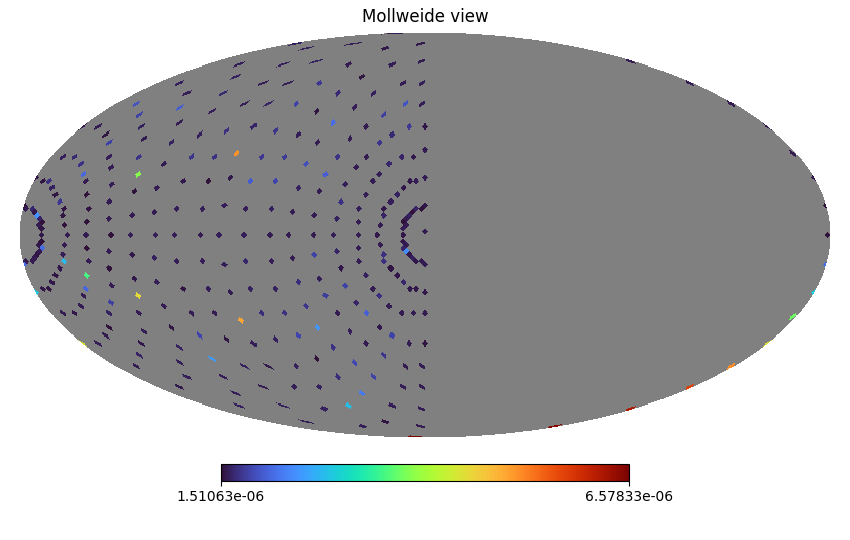

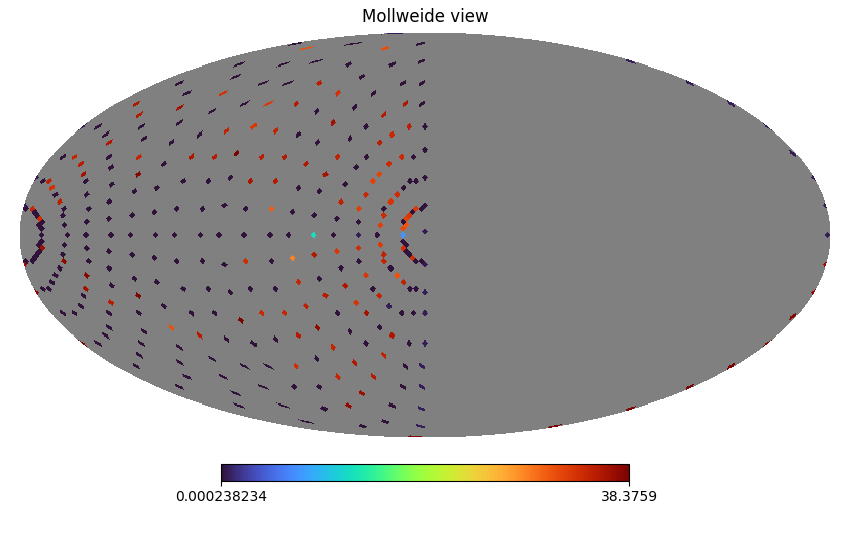

In [251]:
Eth_map = np.full(shape=(hp.nside2npix(nside)), fill_value=hp.UNSEEN)
Eph_map = np.copy(Eth_map)
Eth_map[idx] = final_Eth
Eph_map[idx] = final_Eph
hp.mollview(Eth_map, cmap='turbo')
hp.mollview(Eph_map, cmap='turbo')

In [252]:
Dt

0.0021437504119852816

In [259]:
import numpy as np
import jax
import jax.numpy as jnp
from scipy.sparse.linalg import LinearOperator

R = 10
Dt = 3/2
def friis_model(x):
    Etheta, Ephi = unpack(x)
    y = friis(freqs[freq_ind], R, 10**(s11_t[:, freq_ind]/10), 10**(s11_bowtie[:, freq_ind]/10), Dt, Etheta, Ephi, test_ang, theta, phi, all_freq=False)
    return jnp.asarray(y)  # (361,), real


def pack(Etheta, Ephi):
    Etheta = jnp.asarray(Etheta); Ephi = jnp.asarray(Ephi)
    return jnp.concatenate([jnp.real(Etheta), jnp.real(Ephi),
                            jnp.imag(Etheta), jnp.imag(Ephi)], axis=0)

def unpack(x):
    x = jnp.asarray(x)
    n = 361
    ReEt = x[0:n]
    ReEp = x[n:2*n]
    ImEt = x[2*n:3*n]
    ImEp = x[3*n:4*n]
    Etheta = ReEt + 1j*ImEt
    Ephi   = ReEp + 1j*ImEp
    return Etheta, Ephi

def make_J_operator(x0, friis_model):
    """
    friis_model: callable x -> y, with x shape (n,), y shape (m,)
    """
    x0 = jnp.asarray(x0)

    def matvec(dx):
        dx = jnp.asarray(dx).reshape(-1)          # <- force (n,)
        _, jdx = jax.jvp(friis_model, (x0,), (dx,))
        return np.asarray(jdx).reshape(-1)        # <- force (m,)

    def rmatvec(dy):
        dy = jnp.asarray(dy).reshape(-1)          # <- force (m,)
        y0, pullback = jax.vjp(friis_model, x0)
        dy = dy.reshape(y0.shape)                 # <- match exactly, usually (m,)
        (jTdy,) = pullback(dy)
        return np.asarray(jTdy).reshape(-1)       # <- force (n,)

    m = int(np.prod(np.asarray(friis_model(x0)).shape))
    n = int(np.prod(np.asarray(x0).shape))
    return LinearOperator((m, n), matvec=matvec, rmatvec=rmatvec, dtype=np.float32)


Jop = make_J_operator(x0=pack(th_init, ph_init), friis_model=friis_model)

from scipy.sparse.linalg import svds
# svds returns largest by default if which='LM'
U, s, Vt = svds(Jop, k=10, which='LM')  # top 10

from scipy.sparse.linalg import eigsh

def make_JtJ_operator(Jop):
    n = Jop.shape[1]
    def mv(v):
        return Jop.rmatvec(Jop.matvec(v))
    return LinearOperator((n, n), matvec=mv, dtype=np.float64)

JtJ = make_JtJ_operator(Jop)
# Smallest eigenvalues of J^T J (near-zero => degenerate)
evals, evecs = eigsh(JtJ, k=10, which='SM')  # 10 smallest
singular_vals_small = np.sqrt(np.clip(evals, 0, None))
# dEtheta, dEphi = unpack(v)
dEtheta, dEphi = unpack(evecs[:, 0])
# visualize |dEtheta|, |dEphi| on your sphere to see “what pattern can move freely”


In [281]:
Jop.shape

(361, 1444)

In [261]:
dEtheta.shape, Vt.shape

((361,), (10, 1444))

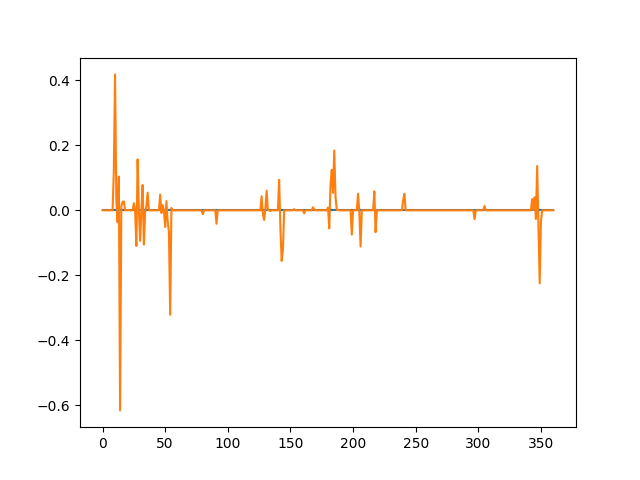

In [260]:
plt.figure()
plt.plot(dEtheta.real)
plt.plot(dEphi.real)
# plt.plot(dEtheta.imag)
plt.show()

TypeError: '_CustomLinearOperator' object is not subscriptable

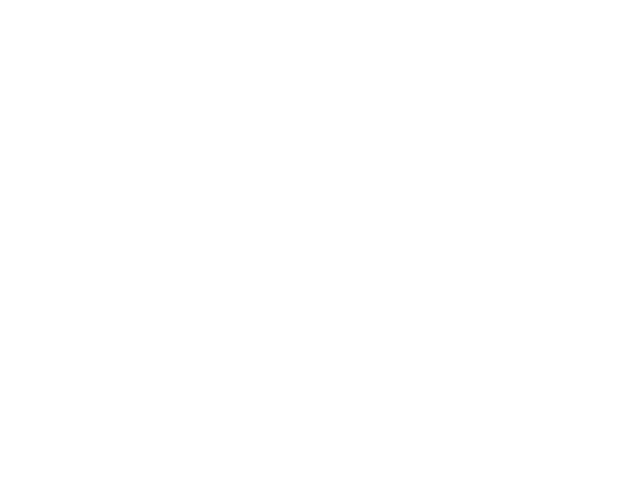

In [282]:
plt.figure()
plt.plot(Jop[0])
plt.show()

In [ ]:
<3